# COE 311K Final Project - Part 1
Pressley Welsh - pbw466
Mary Grayson Horton - mh63289

## Introduction and Model Selection

We have chosen the Spring-Mass System and will be applying it to a Mountain bike suspension after hitting a bump. We chose this model because Spring-Mass is something we have worked without throughout many of our courses, such as statics, dynamics, and physics. A rider hitting a bump is a clear application because the suspension absorbs the impact and return to the original state.
The governing second-order ODE is:
```m * dt^2/d^2y ​+ c * dt/dy​ + ky = 0 ```

The variables included:
- m: mass (kg)
- c: damping coefficient (N·s/m)
- k: spring constant (N/m)
- y(t): displacement from equilibrium (m)

The spring force attempts to restore equilibrium while the damping coefficient resists motion.

I then converted to a system of first-order ODEs:
- ```dy1/dt = y2```
- ```dy2/dt = -c/m * y2 - k/m * y1 ```

This form allows me to apply RK4 or Euler's.

## Parameter Research and Justification

For our model, we used the Trek Slash 9.8 equipped with a Fox DHX2 rear shock as our reference bike.
### Parameters


| Parameter | Value | Units | Source |
|-----------|-------|-------|--------|
| Bike mass | 13.15 | kg | Trek Bikes [1] |
| Rider mass | 90.26 | kg | CDC [2] |
| Total mass | 103.41 | kg | Combined |
| Spring constant | 123,000 | N/m | Trek Bikes [1] |
| Damping coefficient | 3,000 | N*s/m | Vibrations Report [3] |

### Initial Conditions
We have chosen y1(0)=0.03 m, due to an initial compression from hitting the bump. We have chosen y2(0)=0 because we are representing the moment after the wheel hits the bump. We have chosen these to reflect a realistic instance in which this would occur.

### Sources
[1] Trek Bikes. *Slash 9.8*. https://www.trekbikes.com/us/en_US/bikes/mountain-bikes/trail-mountain-bikes/slash/slash-9-8/p/28516/  
[2] CDC. *Body Measurements*. https://www.cdc.gov/nchs/fastats/body-measurements.htm  
[3] Rogers, D. *Mountain Bike Rear Suspension Damping Analysis*. https://dean-rogers-portfolio.github.io/assets/doc/vibrations_report.pdf

## Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 103.4148     # Total mass of rider + bike (kg)
c = 3000         # Damping coefficient (N*s/m)
k = 123000       # Spring constant (N/m)

h_values = [0.001, 0.005, 0.01]  # Different step sizes
t_start = 0      # Start time
t_end = 2        # End time
y_0 = 0.03       # Initial displacement (m)
v_0 = 0.0        # Initial velocity (m/s)

In [2]:
# Function to apply Euler's Method for given step size
def euler_method(h, m, c, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-(c/m) * v_n - (k/m) * y_n)

    return t_values, y_values, v_values

In [3]:
# Define the ODE system
def f(t, y):
    y1 = y[0]   # displacement
    y2 = y[1]   # velocity

    dy1dt = y2
    dy2dt = -(c/m) * y2 - (k/m) * y1

    return np.array([dy1dt, dy2dt])

In [4]:
# Implement the RK4 method
def runge_kutta_4(f, y0, t0, tf, h):
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros((len(t_values), 2))

    # Set the initial condition
    y_values[0] = y0

    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]

        k1 = h * f(t, y)
        k2 = h * f(t + h / 2, y + k1 / 2)
        k3 = h * f(t + h / 2, y + k2 / 2)
        k4 = h * f(t + h, y + k3)

        # Update y based on the RK4 formula
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    return t_values, y_values

We applied both Euler's and RK4 as functions, with the system of first-order ODEs defined in its own function. This avoids having to write the same code multiple times.

### Euler's Forward
Euler's forward is calculated using the information from the current step. This results in larger step sizes having larger error.

### Runge-Katta
RK4 calculates the derivative at 4 points at each step. When using smaller h values, you get a significantly improved accuracy.  

## Solutions and Comparison

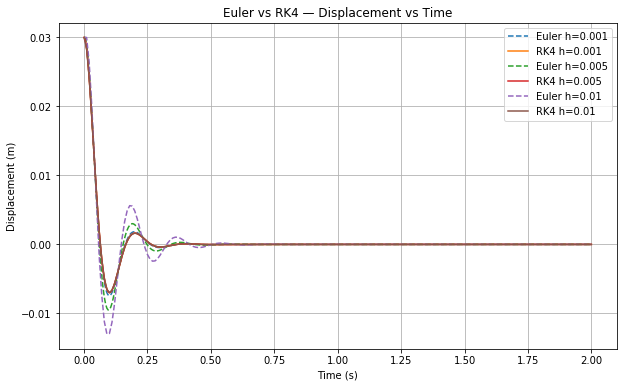

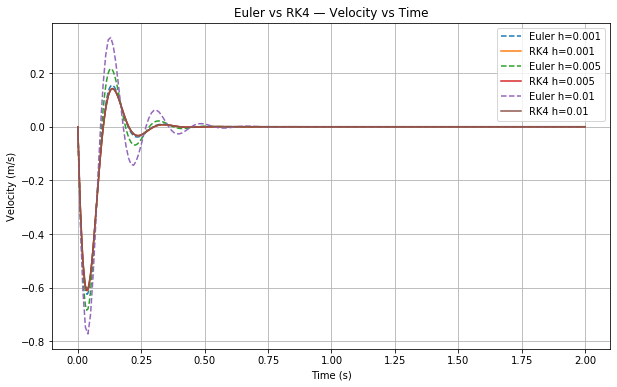

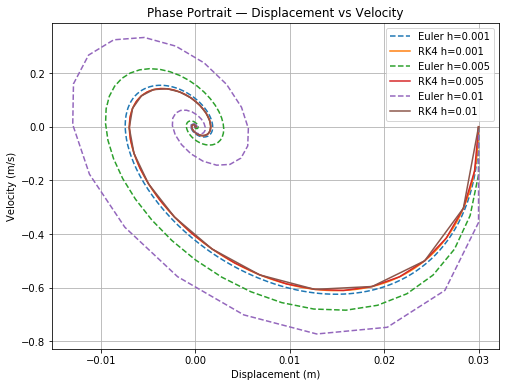

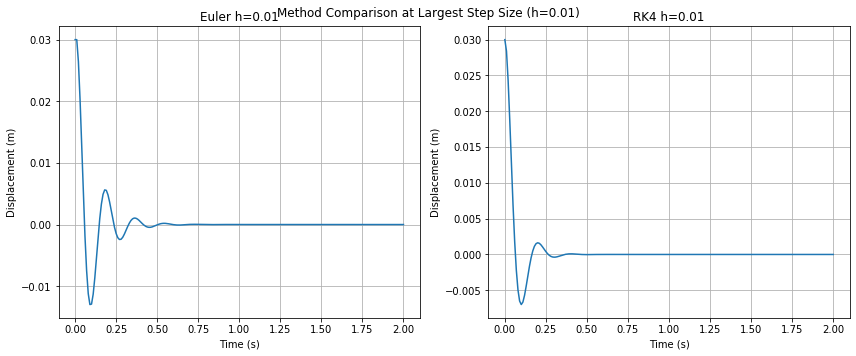

In [5]:
y0 = np.array([y_0, v_0])

# --- Displacement vs Time ---
plt.figure(figsize=(10, 6))

for h in h_values:
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_euler, y_euler, '--', label=f'Euler h={h}')

    t_rk4, y_rk4 = runge_kutta_4(f, y0, t_start, t_end, h)
    plt.plot(t_rk4, y_rk4[:, 0], label=f'RK4 h={h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Euler vs RK4 — Displacement vs Time')
plt.legend()
plt.grid(True)
plt.show()

# --- Velocity vs Time ---
plt.figure(figsize=(10, 6))

for h in h_values:
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_euler, v_euler, '--', label=f'Euler h={h}')

    t_rk4, y_rk4 = runge_kutta_4(f, y0, t_start, t_end, h)
    plt.plot(t_rk4, y_rk4[:, 1], label=f'RK4 h={h}')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Euler vs RK4 — Velocity vs Time')
plt.legend()
plt.grid(True)
plt.show()

# --- Phase Portrait ---
plt.figure(figsize=(8, 6))

for h in h_values:
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(y_euler, v_euler, '--', label=f'Euler h={h}')

    t_rk4, y_rk4 = runge_kutta_4(f, y0, t_start, t_end, h)
    plt.plot(y_rk4[:, 0], y_rk4[:, 1], label=f'RK4 h={h}')

plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Phase Portrait — Displacement vs Velocity')
plt.legend()
plt.grid(True)
plt.show()

# Side by side comparison at h=0.1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

t_euler, y_euler, v_euler = euler_method(0.01, m, c, k, t_start, t_end, y_0, v_0)
t_rk4, y_rk4 = runge_kutta_4(f, y0, t_start, t_end, 0.01)

axes[0].plot(t_euler, y_euler)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Displacement (m)')
axes[0].set_title('Euler h=0.01')
axes[0].grid(True)

axes[1].plot(t_rk4, y_rk4[:, 0])
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Displacement (m)')
axes[1].set_title('RK4 h=0.01')
axes[1].grid(True)

plt.suptitle('Method Comparison at Largest Step Size (h=0.01)')
plt.tight_layout()
plt.show()

We simulated 2 seconds of the suspension response after hitting a bump, starting at 3 cm of compression with zero initial velocity. We tested both methods at three step sizes (h = 0.001, 0.005, 0.01).

The displacement graph shows the suspension rebounding from 3 cm, oscillating, and returning to equilibrium at about 0.5 seconds. Euler's oscillation amplitude appears to be getting smaller as the h value decreases. In contrast, RK4 appears to be consistent across the h sizes.

The velocity graph appears to follow this trend: Euler has a high oscillation amplitude at the largest h and decreases as the step size decreases.

The phase portrait is the most telling of these graphs. RK4 produces a tighter spiral. Euler's spirals are noticeably wider and not as accurate compared to RK4. This is the most noticeable at the largest step size of h=0.01.

The side by side comparison of h=0.01 is able to provide a clear picture of the difference between the two methods by isolating one line. You are able to clearly see that the decay time of Euler is larger. Euler's oscillations are also noticeably larger in amplitude with the first undershoot reaching around -0.015 m compared to RK4's -0.007 m.

## Stability Analysis

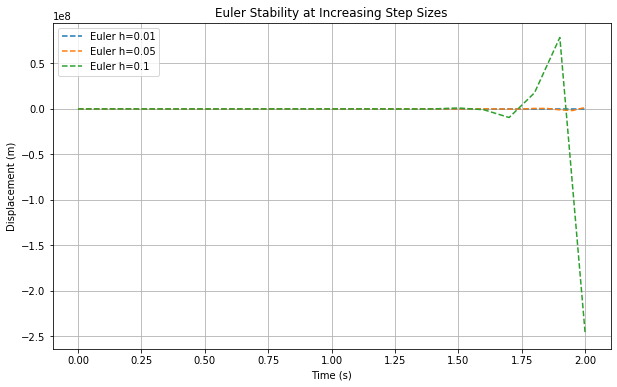

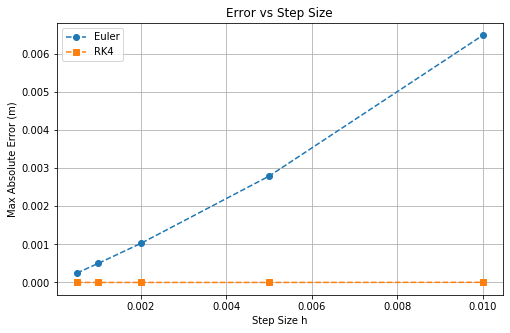

Euler slope: 1.09 (expected ~1)
RK4 slope:   4.03 (expected ~4)


In [6]:
# --- Stability demo ---
plt.figure(figsize=(10, 6))

for h in [0.01, 0.05, 0.1]:
    t_e, y_e, _ = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_e, y_e, '--', label=f'Euler h={h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Euler Stability at Increasing Step Sizes')
plt.legend()
plt.grid(True)
plt.show()

# --- Log-log error plot ---
h_test = [0.0005, 0.001, 0.002, 0.005, 0.01]
euler_errors = []
rk4_errors = []

t_ref, y_ref = runge_kutta_4(f, y0, t_start, t_end, 0.0001)

for h in h_test:
    t_e, y_e, _ = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    t_r, y_r = runge_kutta_4(f, y0, t_start, t_end, h)

    y_ref_e = np.interp(t_e, t_ref, y_ref[:, 0])
    y_ref_r = np.interp(t_r, t_ref, y_ref[:, 0])

    euler_errors.append(np.max(np.abs(y_e - y_ref_e)))
    rk4_errors.append(np.max(np.abs(y_r[:, 0] - y_ref_r)))

plt.figure(figsize=(8, 5))
plt.plot(h_test, euler_errors, 'o--', label='Euler')
plt.plot(h_test, rk4_errors, 's--', label='RK4')
plt.xlabel('Step Size h')
plt.ylabel('Max Absolute Error (m)')
plt.title('Error vs Step Size')
plt.legend()
plt.grid(True)
plt.show()

euler_slope = np.polyfit(np.log(h_test), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(h_test), np.log(rk4_errors), 1)[0]
print(f'Euler slope: {euler_slope:.2f} (expected ~1)')
print(f'RK4 slope:   {rk4_slope:.2f} (expected ~4)')

These graphs shows how sensitive Euler's method is to step sizes. At h=0.1, the displacement shoots up at the end of the simulation. This is not logical for our simulation because the displacement should be returning back to zero. This is a result of h=0.1 being past the stability limit. h=0.01 and h=0.05 are better fits for the simulation, resulting in a more stable line.
The error vs step size graph reinforces this. The RK4 line has significantly less error than the Euler's line throughout the entire graph. The slopes confirm the converge rates. Euler comes out at 1.09 (expected ~1) and RK4 at 4.03 (expected ~4). This means that halfing the step size for Euler's cuts the error in half, while cutting the step size for RK4 cuts the error by a factor of 16. Having a method that converges fast is an important factor in getting a meaningful result.

## Conclusion

By implementing and comparing Euler's Forward and RK4 methods, we have a better understanding of their strengths and limitations in modeling a mountain bike suspension system. The RK4 method outperformed Euler's Forward method for this specific problem. The RK4 method provided more accurate results across different step sizes, better capturing the system's response to the bump impact.

The RK4 method is also the preferred choice when considering computational cost. Although RK4 requires more function evaluations per step compared to Euler's Forward, its higher accuracy allows for larger step sizes while maintaining precision. This means that RK4 can achieve the same accuracy as Euler's Forward with fewer overall steps.

Based on the findings of this project, the RK4 method should be favored over Euler's Forward for simulating similar mechanical systems - it is both more accurate and more cost-effective. However, it is essential to consider the specific requirements of the problem at hand, including the desired level of precision, the computational resources available, and the complexity of the system being modeled.

Throughout this project, several lessons were learned. First, the choice of numerical method directly impacts the accuracy and stability of the solution. Second, stability analysis is important in ensuring that the chosen step sizes yield meaningful results and avoid instabilities. Third, we learned more about connecting the theoretical concepts from class to real-world applications. Using these methods on a tangible situation, like a mountain bike, makes the course material easier to grasp.

In conclusion, the RK4 method proved to be the superior choice for simulating the mountain bike suspension system. This project has helped our understanding of spring-mass systems, and more broadly, how we can use numerical methods to solve real-world engineering problems.